In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import json
import pickle
import matplotlib.image as image
import scipy.stats as stats

In [18]:
sys.path.insert(1, 'utils')
#sys.path.insert(1, '/user/sebert/home/Documents/Repositories/osr_model')
#sys.path.insert(2, '/user/sebert/home/Documents/Repositories/experiments/OSR_Dataanalysis/population_analysis')

In [19]:
#from utils import load_dict, slope_fun
# from load_data import *
# from plot_functions import *
from utils_functions import *
#from utils_exp import *

# Load simulations

In [20]:

# # import params
# with open('data_experiments/params.json') as json_file:
#     params_dynamic = json.load(json_file)
#     print(params_dynamic)

# import simulations


simulation_dynamic_12 = load_dict(f'../output/params_final_nonlin/simulation_osr_12.pickle')
simulation_dynamic_5 = load_dict(f'../output/params_final_nonlin/simulation_osr_5.pickle')


                         
simulations_12 = [simulation_dynamic_12]
simulations_5 = [simulation_dynamic_5]
#simulations_25 = [simulation_dynamic_25]
keys = ['6_Hz', '10_Hz', '16_Hz']

frequencies = simulation_dynamic_12['osrparams']['frequencies']
periods = np.round(1/frequencies,2)*1000

times = [simulation_dynamic_12['simulations'][key]['time']-simulation_dynamic_12['simulations'][key]['lastflash_tp']
         for key in keys]
times_5 = [simulation_dynamic_5['simulations'][key]['time']-simulation_dynamic_5['simulations'][key]['lastflash_tp']
         for key in keys]
flashes =[np.where(np.diff(simulation_dynamic_12['simulations'][key]['stimulus']) != 0)[0].tolist() for key in keys]

lastflashends = [simulation_dynamic_12['simulations'][key]['lastflash_tp'] for key in keys]
lastflashends_5 = [simulation_dynamic_5['simulations'][key]['lastflash_tp'] for key in keys]


# simulation 12 flashes
responses_dynamic_12 = [simulation_dynamic_12['simulations'][key]['RG'] for key in keys]
delays_dynamic_12 = [simulation_dynamic_12['simulations'][key]['delay'] for key in keys]
peak_amps_dynamic_12 = [simulation_dynamic_12['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_dynamic_12 = simulation_dynamic_12['delays']*1000
slope_dynamic_12 = simulation_dynamic_12['slope']
offset_dynamic_12 =  simulation_dynamic_12['offset']*1000

all_peak_amps_dynamic_12 = simulation_dynamic_12['peak_amplitudes']

# simulation 5 flashes
responses_dynamic_5 = [simulation_dynamic_5['simulations'][key]['RG'] for key in keys]
delays_dynamic_5 = [simulation_dynamic_5['simulations'][key]['delay'] for key in keys]
peak_amps_dynamic_5 = [simulation_dynamic_5['simulations'][key]['peak_amplitude'] for key in keys]

delays_all_dynamic_5 = simulation_dynamic_5['delays']*1000
slope_dynamic_5 = simulation_dynamic_5['slope']
offset_dynamic_5 =  simulation_dynamic_5['offset']*1000

all_peak_amps_dynamic_5 = simulation_dynamic_5['peak_amplitudes']



In [21]:
simulation_dynamic_12.keys()
simulation_dynamic_12['simulations']['6_Hz'].keys()

dict_keys(['name', 'stimulus', 'time', 'OPL_inputs', 'OPL_inputs_raw', 'OPL_inputs_rec', 'sol', 'RG', 'lastflash_tp', 'frequency', 'peak_amplitude', 'delay', 'max_occupancy'])

# Load data

In [22]:

# load cells dict
filename = f"../data_experiments/data_cells_with_OSR_12.pkl"
with open(filename, "rb") as handle:   #Pickling
    cells_dict_12 = pickle.load(handle)
    
# load cells dict
filename = f"../data_experiments/data_cells_with_OSR_5.pkl"
with open(filename, "rb") as handle:   #Pickling
    cells_dict_5 = pickle.load(handle)

In [23]:
cells_dict_5['mean'].keys()

dict_keys(['mean_peaks_control', 'all_slopes_control', 'mean_slopes_control', 'mean_offset_control', 'all_amps_control', 'all_delays_control', 'mean_amps_control'])

In [24]:
# 12 flashes
mean_delays_12 = cells_dict_12['mean']['mean_peaks_control']
mean_amps_12 = cells_dict_12['mean']['mean_amps_control']

std_delays_12 = cells_dict_12['std']['std_peaks_control']
std_amps_12 = cells_dict_12['std']['std_amps_control']

mean_slope_12 = cells_dict_12['mean']['mean_slopes_control']
mean_offset_12 = cells_dict_12['mean']['mean_offset_control']

all_slopes_12 = cells_dict_12['mean']['all_slopes_control']
all_amps_12 = cells_dict_12['mean']['all_amps_control']
all_delays_12 = cells_dict_12['mean']['all_delays_control']


# 5 flashes
mean_delays_5 = cells_dict_5['mean']['mean_peaks_control']
mean_amps_5 = cells_dict_5['mean']['mean_amps_control']

std_delays_5 = cells_dict_5['std']['std_peaks_control']
std_amps_5 = cells_dict_5['std']['std_amps_control']

mean_slope_5 = cells_dict_5['mean']['mean_slopes_control']
mean_offset_5 = cells_dict_5['mean']['mean_offset_control']

all_slopes_5 = cells_dict_5['mean']['all_slopes_control']
all_amps_5 = cells_dict_5['mean']['all_amps_control']
all_delays_5 = cells_dict_5['mean']['all_delays_control']


sem_slope_12 = calculate_std(all_slopes_12)
sem_slope_5 = calculate_std(all_slopes_5)

In [25]:
cells_dict_5['mean'].keys()

dict_keys(['mean_peaks_control', 'all_slopes_control', 'mean_slopes_control', 'mean_offset_control', 'all_amps_control', 'all_delays_control', 'mean_amps_control'])

# Correlation between amplitude and flash number

In [26]:
# calculate correlation of amplitude  means
print(f'correlation exp {np.corrcoef(periods, mean_amps_12)[0][1]:.2f}')
print(f'correlation sim {np.corrcoef(periods, all_peak_amps_dynamic_12)[0][1]:.2f}')


correlation exp -0.88
correlation sim -0.93


In [27]:
#### calculate correlation individual amplitudes
corrcoefs_12 = []
for amps in all_amps_12:
    corrcoefs_12.append(np.corrcoef(periods, amps)[0][1])
 
sem_amps_corrcoef_12 = calculate_std(corrcoefs_12)

corrcoefs_5 = []
for amps in all_amps_5:
    corrcoefs_5.append(np.corrcoef(periods, amps)[0][1])

sem_amps_corrcoef_5 = calculate_std(corrcoefs_5)
    
print(f'correlation exp 12 {np.nanmean(corrcoefs_12):.2f}')
print(f's. e. m. {sem_amps_corrcoef_12}')
print(f'correlation exp 5 {np.nanmean(corrcoefs_5):.2f}')
print(f's. e. m. {sem_amps_corrcoef_5}')

    

correlation exp 12 -0.87
s. e. m. 0.022460312899977988
correlation exp 5 -0.81
s. e. m. 0.04767285093246886


# amplitude change 12 vs 5

In [28]:
pvalues = []
for i in range(len(frequencies)):
    stat, p = stats.ttest_rel(np.asarray(all_amps_12)[:,i],
                              np.asarray(all_amps_5)[:,i] ,
                              nan_policy='omit')        
    pvalues.append(p)
    #significance_amps.append(evaluate_significance(p))
    #significance_amps.append(evaluate_significance_bonferroni(p,5))

    
#significance_amps = np.flip(significance_amps)

In [30]:
significance_amps = evaluate_significance_bonferroni_holm(pvalues,frequencies)

***, p = 6.11e-06
**, p = 1.49e-03
ns, p = 3.11e-02
ns, p = 4.22e-02
ns, p = 1.98e-01


/Users/simone/Documents/Repositories/osr_model/Figure_codes/utils/utils_functions.py:180: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvalues_df['significance'].iloc[i] = "***"
/Users/simone/Documents/Repositories/osr_model/Figure_codes/ut

In [31]:
significance_amps

[[0.1976956926447149, 'ns'],
 [0.04221744222586685, 'ns'],
 [0.00149336135262492, '**'],
 [0.031111391054266215, 'ns'],
 [6.109223632495553e-06, '***']]

# slope change 5 vs 12

In [32]:
# calculate mean and sem for slope change 5 vs 12 frequencies
print(f'mean slope control: {mean_slope_12}')
print(f's. e. m. : {sem_slope_12}')
print(f'mean slope strychnine: {mean_slope_5}')
print(f's. e. m. : {sem_slope_5}')


mean slope control: 0.8394049847473449
s. e. m. : 0.02207705371978593
mean slope strychnine: 0.6957149037916469
s. e. m. : 0.04379370508047801


# latency change

In [33]:
#significance_delays = []
pvalues_delays = []
for i in range(len(frequencies)):
    stat, p = stats.ttest_rel(np.asarray(all_delays_12)[:,i],
                              np.asarray(all_delays_5)[:,i] ,
                              nan_policy='omit')        
    #significance_delays.append(evaluate_significance_bonferroni(p,5))
    #significance_delays.append(evaluate_significance(p))
    pvalues_delays.append(p)

    

In [34]:
significance_delays = evaluate_significance_bonferroni_holm(pvalues_delays,frequencies)

ns, p = 2.40e-02
ns, p = 3.14e-02
ns, p = 4.43e-02
ns, p = 1.41e-01
ns, p = 1.98e-01


In [ ]:

#figure parameter
save = True
figure_name = "Figure_6"
show = True
image_format = "png"
dpi = 300



slope 12 = 1.13
slope 5 = 0.63
6_Hz [0.72290418]
8_Hz [0.65368096]
10_Hz [0.60958899]
12_Hz [0.56278823]
16_Hz [0.49176667]


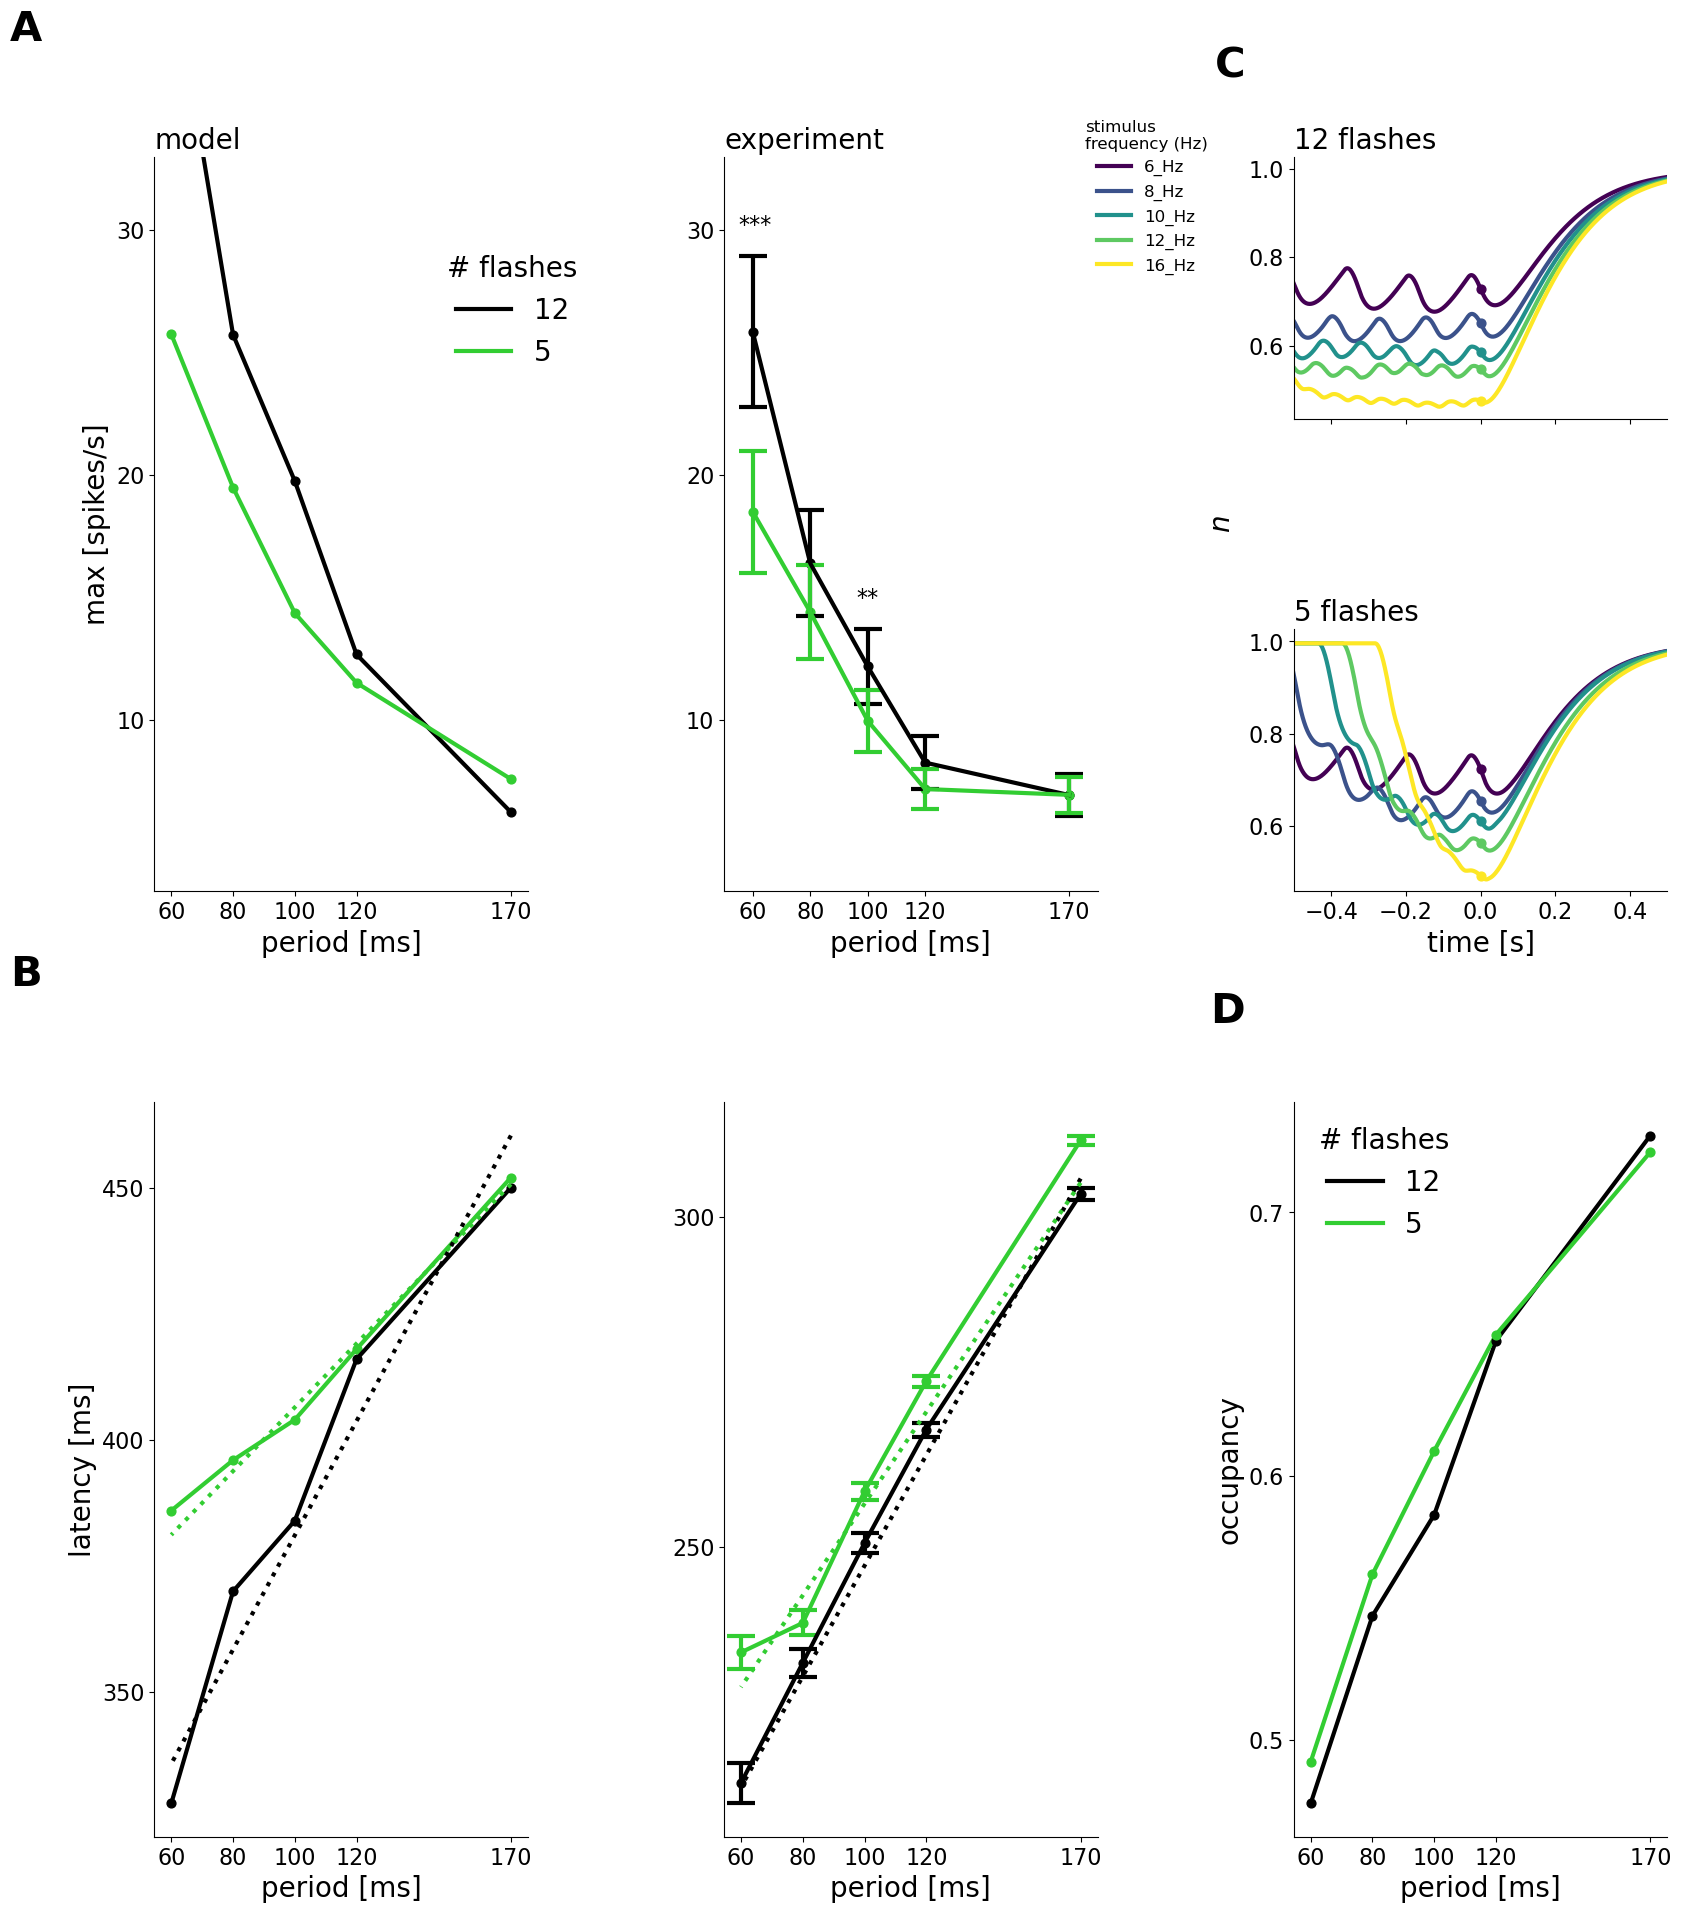

In [40]:
#figure parameter
fontsize_legend = 20
fontsize_labels = 20
fontsize_panellabel = 30
fontsize_ticks = 16
lw = 3
ms = 40
panellabel_position = [-0.13, 1.15]
frequencytext_position = [0.15,1.1]
figsize = (17,20)

#initialize figure
fig = plt.figure(figsize = figsize)
gs = fig.add_gridspec(4,3)
fig.subplots_adjust(top=0.925,
bottom=0.085,
left=0.095,
right=0.985,
hspace=0.805,
wspace=0.525)

shades_of_blue = plt.get_cmap('viridis',5)
color_5 = 'limegreen'



amps_asteriks_xpositions = [165,118,96,79,55]
delays_asteriks_xpositions = [165,115,98,78,58]


#####################################################################################################################
# create panels
#####################################################################################################################


A = fig.add_subplot(gs[0:2,0])
B = fig.add_subplot(gs[0:2,1], sharey = A)
C = fig.add_subplot(gs[2:,0])
D = fig.add_subplot(gs[2:,1])
E = fig.add_subplot(gs[0:2,2])
E0 = fig.add_subplot(gs[0,2])
E1 = fig.add_subplot(gs[1,2])

F = fig.add_subplot(gs[2:,2])

#add panel labels
A.text(*[-0.3, 1.2], 'A', transform=A.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
# B.text(*panellabel_position, 'B', transform=B.transAxes,
#       fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
C.text(*[-0.3, 1.2], 'B', transform=C.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
# D.text(*panellabel_position, 'D', transform=D.transAxes,
#       fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
E.text(*panellabel_position, 'C', transform=E.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
F.text(*panellabel_position, 'D', transform=F.transAxes,
      fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')


#remove frames that are not needed


A.spines['right'].set_visible(False)
A.spines['top'].set_visible(False)
B.spines['right'].set_visible(False)
B.spines['top'].set_visible(False)
C.spines['right'].set_visible(False)
C.spines['top'].set_visible(False)
D.spines['right'].set_visible(False)
D.spines['top'].set_visible(False)
E.spines['right'].set_visible(False)
E.spines['top'].set_visible(False)
F.spines['right'].set_visible(False)
F.spines['top'].set_visible(False)

E0.spines['right'].set_visible(False)
E0.spines['top'].set_visible(False)
E1.spines['right'].set_visible(False)
E1.spines['top'].set_visible(False)

E.spines['left'].set_color('white')
E.tick_params(axis='y', colors='white')
E.spines['bottom'].set_color('white')
E.tick_params(axis='x', colors='white')

# set titles
A.set_title('model',fontsize = fontsize_labels, loc = 'left')
B.set_title('experiment',fontsize = fontsize_labels, loc = 'left')
#C.set_title('model',fontsize = fontsize_labels, loc = 'left')
#D.set_title('experiment',fontsize = fontsize_labels, loc = 'left')
E0.set_title('12 flashes',fontsize = fontsize_labels, loc = 'left')
E1.set_title('5 flashes',fontsize = fontsize_labels, loc = 'left')

# label the axis
A.set_ylabel('max [spikes/s]',fontsize = fontsize_labels)
A.set_xlabel('period [ms]',fontsize = fontsize_labels)
B.set_xlabel('period [ms]', fontsize = fontsize_labels)
C.set_ylabel('latency [ms]', fontsize = fontsize_labels)
C.set_xlabel('period [ms]', fontsize = fontsize_labels)
D.set_xlabel('period [ms]', fontsize = fontsize_labels)
F.set_xlabel('period [ms]',  fontsize = fontsize_labels)
F.set_ylabel('occupancy',  fontsize = fontsize_labels)
E1.set_xlabel('time [s]',  fontsize = fontsize_labels)
E.set_ylabel('$n$',  fontsize = fontsize_labels)

# format ticks
A.locator_params(axis = 'y', nbins=3)
B.locator_params(axis = 'y', nbins=3)
C.locator_params(axis = 'y', nbins=3)
D.locator_params(axis = 'y', nbins=3)
E.locator_params(axis = 'y', nbins=3)
F.locator_params(axis = 'y', nbins=3)

A.set_xticks(periods)
A.set_xticklabels(['170', '120'  , '100' , '80', '60'])
B.set_xticks(periods)
B.set_xticklabels(['170', '120'  , '100' , '80', '60'])
C.set_xticks(periods)
C.set_xticklabels(['170', '120'  , '100' , '80', '60'])
D.set_xticks(periods)
D.set_xticklabels(['170', '120'  , '100' , '80', '60'])
F.set_xticks(periods)
F.set_xticklabels(['170', '120'  , '100' , '80', '60'])

E0.tick_params('x', labelbottom=False)
E1.locator_params(axis = 'x', nbins=5)

A.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
A.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
B.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
B.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
C.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
C.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
D.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
D.tick_params(axis='both', which='major', labelsize=fontsize_ticks)

E0.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
E0.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
E1.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
E1.tick_params(axis='both', which='major', labelsize=fontsize_ticks)
F.tick_params(axis='both', which='minor', labelsize=fontsize_ticks)
F.tick_params(axis='both', which='major', labelsize=fontsize_ticks)



B.set_xlim(50,180)
B.set_ylim(3,33)
E1.set_xlim(-.5,.5 )
E0.set_xlim(-.5,.5)

#############################################################################################
# fill panels
#############################################################################################

# panel 1: amplitude  simulation


amps = []
for key in simulation_dynamic_12['simulations']:
    amps.append(simulation_dynamic_12['simulations'][key]["peak_amplitude"])
    
    
A.plot(periods,amps, label = '12', color = 'k', linewidth = lw)
A.scatter(periods,amps, color = 'k', s = ms)

amps = []
for key in simulation_dynamic_5['simulations']:
    amps.append(simulation_dynamic_5['simulations'][key]["peak_amplitude"])

A.plot(periods,amps, label = '5', color = color_5, linewidth = lw)
A.scatter(periods,amps, color = color_5, s = ms)

A.legend(frameon=False, fontsize = fontsize_legend,
              title = "# flashes",
              title_fontsize= fontsize_legend,
              bbox_to_anchor = (1.2,.9))


# panel 2: amplitude experiment
B.scatter(periods,mean_amps_12,s = ms, color = 'k')
B.scatter(periods,mean_amps_5,s = ms, color = color_5)
B.errorbar(periods,mean_amps_12,
           linewidth = lw, label = '12 exp',yerr = std_amps_12,
            capsize = 10, capthick = lw, color = 'k')
B.errorbar(periods,mean_amps_5,
           linewidth = lw, label = '5 exp',yerr = std_amps_5,
            capsize = 10, capthick = lw, color = color_5)

# significance
for i,ask in enumerate(significance_amps):
    if ask[1] != "ns":
        B.text(x=amps_asteriks_xpositions[i], y=mean_amps_12[i]+std_amps_12[i]+1, s=ask[1], 
          fontsize = fontsize_ticks)
    

#panel 3: latency simulation

C.scatter(periods,simulation_dynamic_12['delays']*1000,s = ms,
          color = 'k')
C.scatter(periods,simulation_dynamic_5['delays']*1000,s = ms, 
          color = color_5)

C.plot(periods,simulation_dynamic_12['delays']*1000,linewidth = lw,
       color = 'k', label = '12')
C.plot(periods,simulation_dynamic_5['delays']*1000,linewidth = lw,
       color = color_5, label = '5')

# plot slope
C.plot(periods,
       slope_fun(np.array(periods),simulation_dynamic_12['slope'],simulation_dynamic_12['offset']*1000),
       color = 'k', linestyle = ':', alpha = 1, linewidth = lw)
C.plot(periods,
       slope_fun(np.array(periods),simulation_dynamic_5['slope'],simulation_dynamic_5['offset']*1000),
       color = color_5, linestyle = ':',alpha = 1, linewidth = lw)
s12 = simulation_dynamic_12['slope']
s5 = simulation_dynamic_5['slope']
print(f'slope 12 = {s12:.2f}')
print(f'slope 5 = {s5:.2f}')



# C.legend(frameon=False, fontsize = fontsize_legend,
#               title = "# flashes",
#               title_fontsize= fontsize_legend,
#               bbox_to_anchor = (.55,.75))

# panel 4: latency experiment
D.scatter(periods,mean_delays_12,s = ms, color = 'k')
D.scatter(periods,mean_delays_5,s = ms, color = color_5)
D.errorbar(periods,mean_delays_12,yerr = std_amps_12,linewidth = lw,
           color = 'k', capsize = 10, capthick = lw)
D.errorbar(periods,mean_delays_5,yerr = std_amps_5,linewidth = lw,
           color = color_5, capsize = 10, capthick = lw)

D.plot(periods, slope_fun(np.array(periods),mean_slope_12,mean_offset_12),
       color = 'k', linestyle = ':',linewidth = lw,  alpha = 1)
D.plot(periods, slope_fun(np.array(periods),mean_slope_5,mean_offset_5),
       color = color_5, linestyle = ':',linewidth = lw, alpha = 1)


# significance
for i,ask in enumerate(significance_delays):
    if ask[1] != "ns":
        D.text(x=delays_asteriks_xpositions[i], 
           y=mean_delays_5[i]+std_delays_5[i]+1, s=ask[1], 
          fontsize = fontsize_ticks)

# panel 5: occupancy curves

ns_at_0 = []
for i,key in enumerate(simulation_dynamic_12['simulations']):

    time = simulation_dynamic_12['simulations'][key]["time"]
    lastflashend = simulation_dynamic_12['simulations'][key]['lastflash_tp']
    sol = simulation_dynamic_12['simulations'][key]['sol']
    
    n_at_0 = sol.y[3][np.where((time-lastflashend) == 0)[0]]
    #n_at_0 = time[np.argmin(sol.y[3])]-lastflashend
    
    E0.plot(time-lastflashend,sol.y[3], linewidth = lw,
           color = shades_of_blue(i),label = key)
    #ax.scatter(n_at_0,maxs_n_12[i])
    E0.scatter(0,n_at_0, s = ms, color = shades_of_blue(i))
    ns_at_0.append(n_at_0)
    


ns_at_0_5 = []
for i,key in enumerate(simulation_dynamic_5['simulations']):

    time = simulation_dynamic_5['simulations'][key]["time"]
    lastflashend = simulation_dynamic_5['simulations'][key]['lastflash_tp']
    sol = simulation_dynamic_5['simulations'][key]['sol']
    
    n_at_0 = sol.y[3][np.where((time-lastflashend) == 0)[0]]
    #n_at_0 = time[np.argmin(sol.y[3])]-lastflashend
    
    E1.plot(time-lastflashend,sol.y[3], label = key, linewidth = lw,
           color = shades_of_blue(i))
    E1.scatter(0,n_at_0, s = ms, color = shades_of_blue(i))
#     ax2.scatter(n_at_0,maxs_n_5[i])
    print(key, n_at_0)
    ns_at_0_5.append(n_at_0)
    

E0.legend(frameon=False, fontsize = 12,
              title = "stimulus\nfrequency (Hz)",
              title_fontsize=12, bbox_to_anchor=(-.6, 1.2), loc = 'upper left')
# panel 6: occupancy scaling

F.plot(periods,ns_at_0, color = 'black',
       linewidth = lw, label = '12')

for i,mn in enumerate(ns_at_0):
    F.scatter(periods[i],mn,marker ='o', s = ms,color = 'k', zorder = 10)


F.plot(periods,ns_at_0_5, color = color_5,
       linewidth = lw, label = '5')

for i,mn in enumerate(ns_at_0_5):
    F.scatter(periods[i],mn,marker ='o',color = color_5, s = ms, zorder = 10)


F.legend(frameon=False, fontsize = fontsize_legend,
              title = "# flashes",
              title_fontsize= fontsize_legend)








### Save and show
if save:
    plt.savefig("{}.{}".format(f'../Figures/{figure_name}', image_format), dpi=dpi)
if show:
    plt.show()
else:
    plt.close()
